# Classification

## Import Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score,classification_report, confusion_matrix
import random
import warnings
warnings.filterwarnings('ignore')




In [5]:
# Load and preprocess Iris dataset (same as previous tasks)
iris = load_iris()
df = pd.DataFrame(iris.data,
columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

# Prepare features and target
numeric_features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
X = df[numeric_features].copy()
y = df['species'].copy()

# Apply Min-Max normalization
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Create train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2,
  random_state=42, stratify=y
  )


print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {X_normalized.shape[1]}")
print(f"Classes: {list(y.unique())}")

Training samples: 120
Test samples: 30
Features: 4
Classes: ['setosa', 'versicolor', 'virginica']


## Training Decision tree Classifier

In [6]:
 # Train Decision Tree classifier
dt_classifier = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,  # Prevent overfitting
    min_samples_split=5,
    min_samples_leaf=2
)

# Fit on training data
dt_classifier.fit(X_train, y_train)

# Predict on test set
y_pred_dt = dt_classifier.predict(X_test)

# Calculate performance metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print(f"Decision Tree Results:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

# Detailed classification report
print(f"\n Detailed Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
print(f"\n Confusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_df = pd.DataFrame(cm_dt,
                     index=dt_classifier.classes_,
                     columns=dt_classifier.classes_)
print(cm_df)

Decision Tree Results:
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666

 Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


 Confusion Matrix:
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0           9          1
virginica        0           0         10


## Visualising the Tree

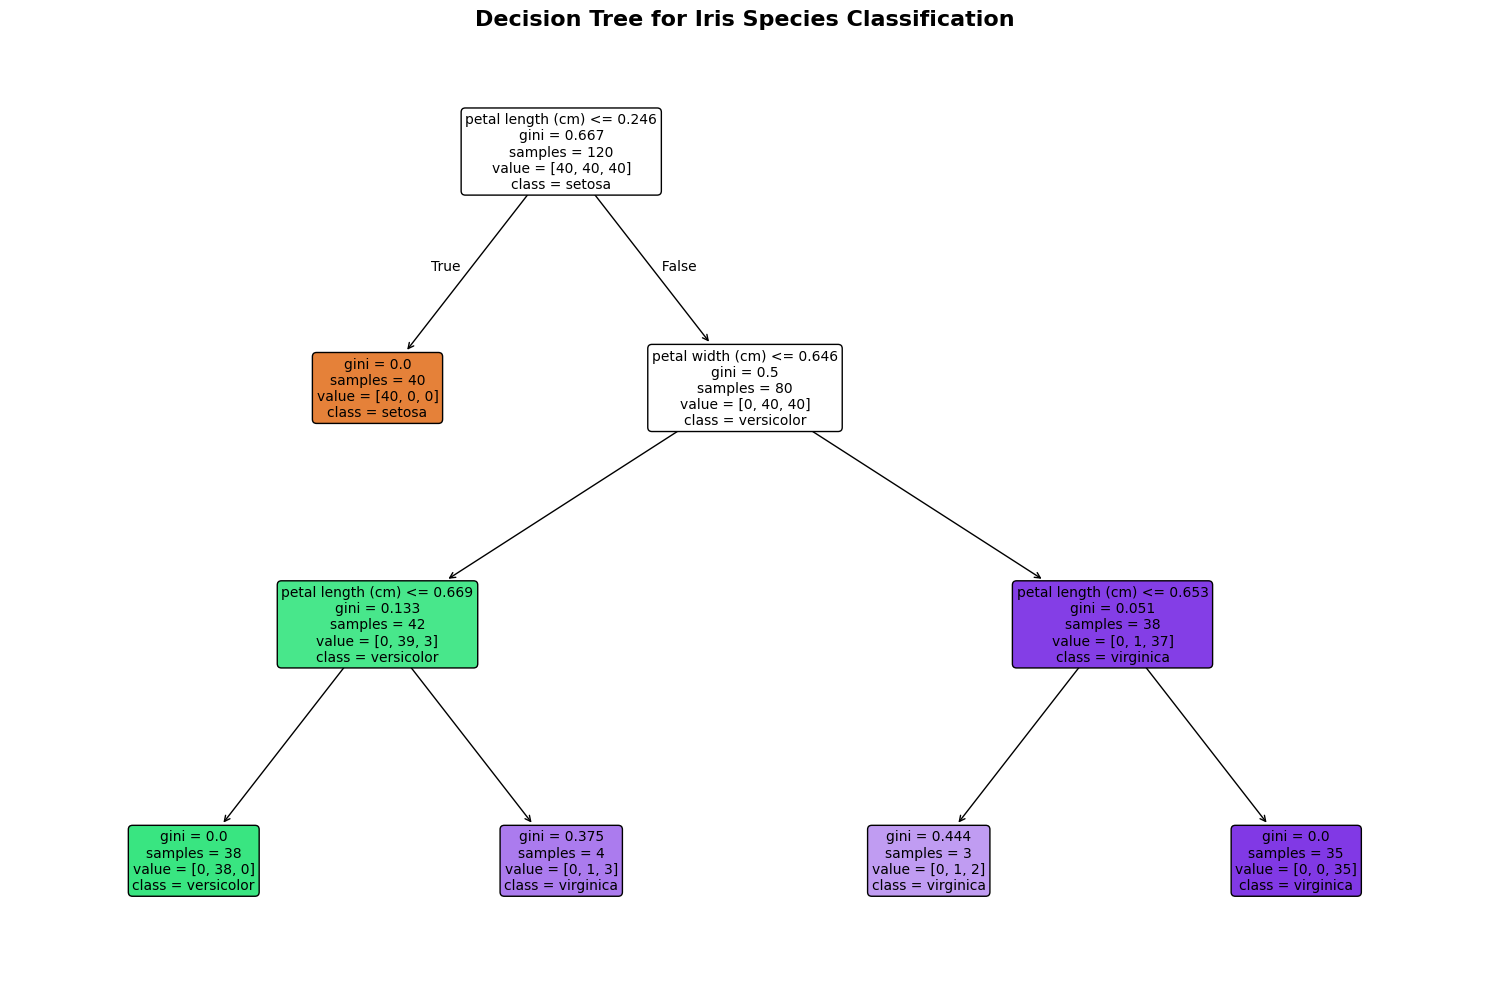


 Feature Importance:
             feature  importance
2  petal length (cm)    0.579077
3   petal width (cm)    0.420923
0  sepal length (cm)    0.000000
1   sepal width (cm)    0.000000


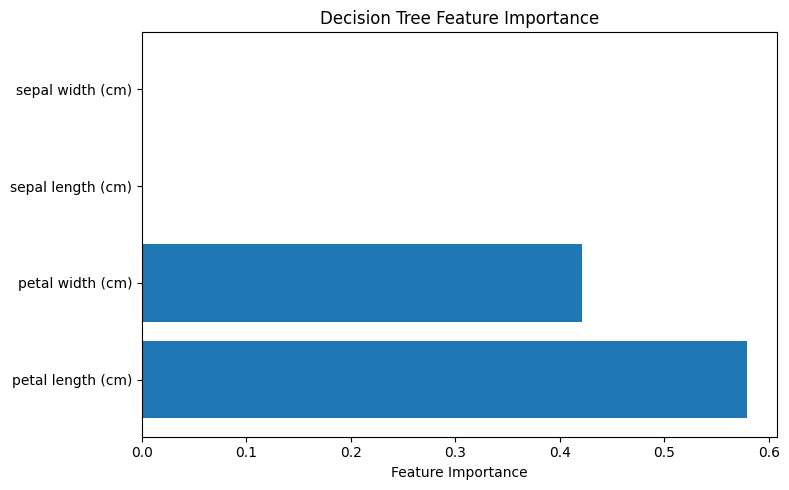

In [7]:
plt.figure(figsize=(15, 10))
plot_tree(dt_classifier,
        feature_names=numeric_features,
        class_names=dt_classifier.classes_,
        filled=True,
        rounded=True,
        fontsize=10)
plt.title('Decision Tree for Iris Species Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_iris.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature importance
print(f"\n Feature Importance:")
feature_importance = pd.DataFrame({
    'feature': numeric_features,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'],
feature_importance['importance'])
plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300,
bbox_inches='tight')
plt.show()



## Comparing Decision Tree vs KNN 

In [9]:
# Compare Decision Tree with KNN classifier (k=5)
print("Comparing with K-Nearest Neighbors (k=5)")

# Train KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train, y_train)

# Predict on test set
y_pred_knn = knn_classifier.predict(X_test)

# Calculate KNN performance metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print(f" KNN (k=5) Results:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")

# Comparison summary
print(f"\n Classifier Comparison:")
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [accuracy_dt, precision_dt, recall_dt, f1_dt],
    'KNN (k=5)': [accuracy_knn, precision_knn, recall_knn, f1_knn]
})

print(comparison_df.round(4))

# Determine which is better
if accuracy_dt > accuracy_knn:
    better_classifier = "Decision Tree"
    better_score = accuracy_dt
    reason = "Higher accuracy and better interpretability through clear decision rules"
else:
    better_classifier = "KNN"
    better_score = accuracy_knn
    reason = "Higher accuracy with distance-based classification"

print(f"\n Winner: {better_classifier}")
print(f"Best accuracy: {better_score:.4f}")
print(f"Reason: {reason}")


Comparing with K-Nearest Neighbors (k=5)
 KNN (k=5) Results:
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666

 Classifier Comparison:
      Metric  Decision Tree  KNN (k=5)
0   Accuracy         0.9667     0.9667
1  Precision         0.9697     0.9697
2     Recall         0.9667     0.9667
3   F1-Score         0.9666     0.9666

 Winner: KNN
Best accuracy: 0.9667
Reason: Higher accuracy with distance-based classification


# Association Rule Mining

In [ ]:
# Part B: Association Rule Mining
print("🛒 Generating synthetic transactional data...")

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Define item pool (grocery items)
items_pool = [
    'milk', 'bread', 'beer', 'diapers', 'eggs', 'butter', 'cheese',
    'apples', 'bananas', 'coffee', 'tea', 'sugar', 'flour', 'rice',
    'pasta', 'tomatoes', 'onions', 'chicken', 'beef', 'fish'
]

print(f"Item pool: {len(items_pool)} items")
print(f"Items: {items_pool}")

# Generate transactions with realistic patterns
transactions = []
num_transactions = 50  # As specified in exam requirements

# Create some frequent itemsets with higher probability
frequent_patterns = [
    ['milk', 'bread'],           # Basic necessities
    ['beer', 'diapers'],         # Famous marketing example  
    ['coffee', 'sugar'],         # Natural combination
    ['bread', 'butter'],         # Complementary items
    ['apples', 'bananas'],       # Fresh fruits together
    ['chicken', 'rice'],         # Meal components
    ['pasta', 'tomatoes'],       # Cooking ingredients
    ['milk', 'eggs', 'butter']   # Baking ingredients
]

print(f"\n📊 Generating {num_transactions} transactions...")

for i in range(num_transactions):
    transaction = []
    
    # 30% chance to include a frequent pattern
    if random.random() < 0.3:
        pattern = random.choice(frequent_patterns)
        transaction.extend(pattern)
    
    # Add 2-6 additional random items
    num_additional = random.randint(2, 6)
    additional_items = random.sample(items_pool, min(num_additional, len(items_pool)))
    
    # Combine and remove duplicates
    transaction.extend(additional_items)
    transaction = list(set(transaction))  # Remove duplicates
    
    transactions.append(transaction)

# Display sample transactions
print(f"✅ Generated {len(transactions)} transactions")
print(f"\nSample transactions:")
for i in range(5):
    print(f"Transaction {i+1}: {transactions[i]}")

# Basic statistics
transaction_lengths = [len(t) for t in transactions]
print(f"\nTransaction statistics:")
print(f"Average items per transaction: {np.mean(transaction_lengths):.1f}")
print(f"Min items: {min(transaction_lengths)}")
print(f"Max items: {max(transaction_lengths)}")

# Most frequent individual items
all_items = [item for transaction in transactions for item in transaction]
item_counts = pd.Series(all_items).value_counts()
print(f"\nTop 10 most frequent items:")
print(item_counts.head(10))

In [ ]:
# Install mlxtend if not available and import required libraries
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("✅ mlxtend library is available")
except ImportError:
    print("📦 Installing mlxtend library...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'mlxtend'])
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("✅ mlxtend library installed and imported")